In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import os 

In [2]:
df = pd.read_csv(r"G:\My Drive\pandas\project 7\Bank Customer Churn Prediction.csv")

In [3]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.info()

df.isnull().sum()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [9]:
df.drop_duplicates(inplace=True)

In [8]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [10]:
df.columns.value_counts()

customer_id         1
credit_score        1
country             1
gender              1
age                 1
tenure              1
balance             1
products_number     1
credit_card         1
active_member       1
estimated_salary    1
churn               1
Name: count, dtype: int64

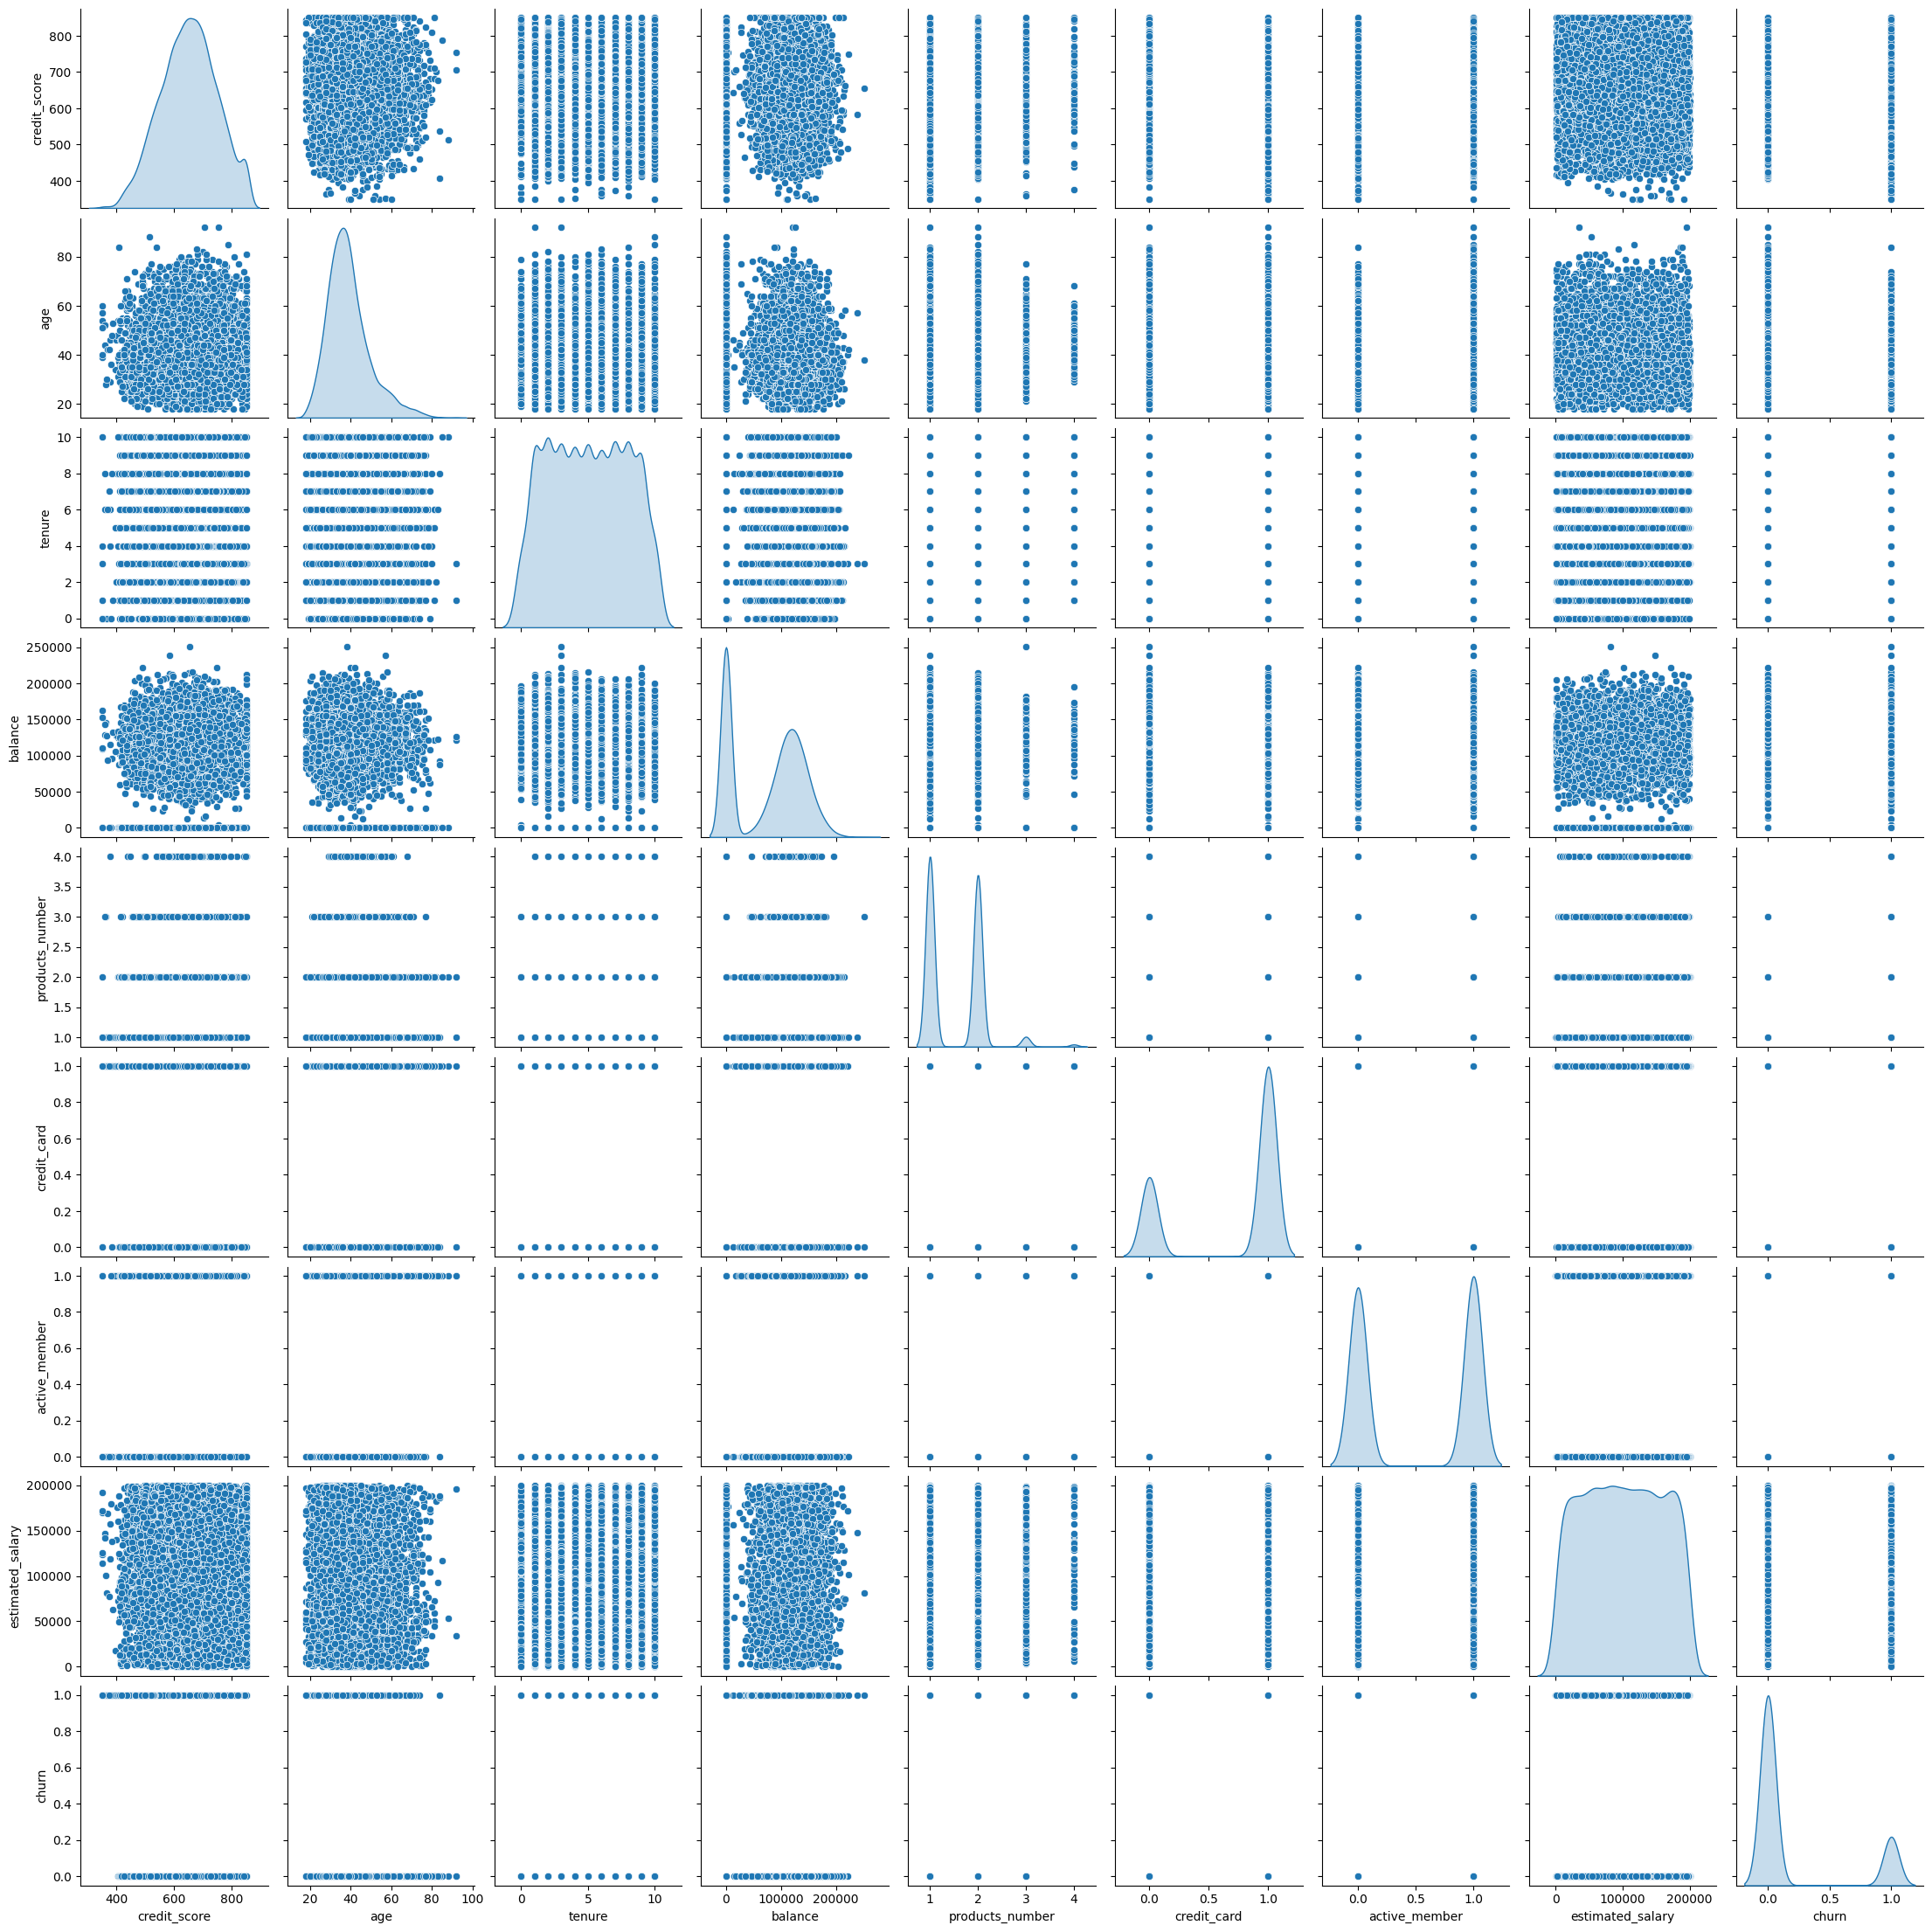

In [23]:

multiplegraph = ['credit_score','age','country','gender','tenure','balance','products_number','credit_card','active_member','estimated_salary','churn']
sns.pairplot(df[multiplegraph],diag_kind='kde')

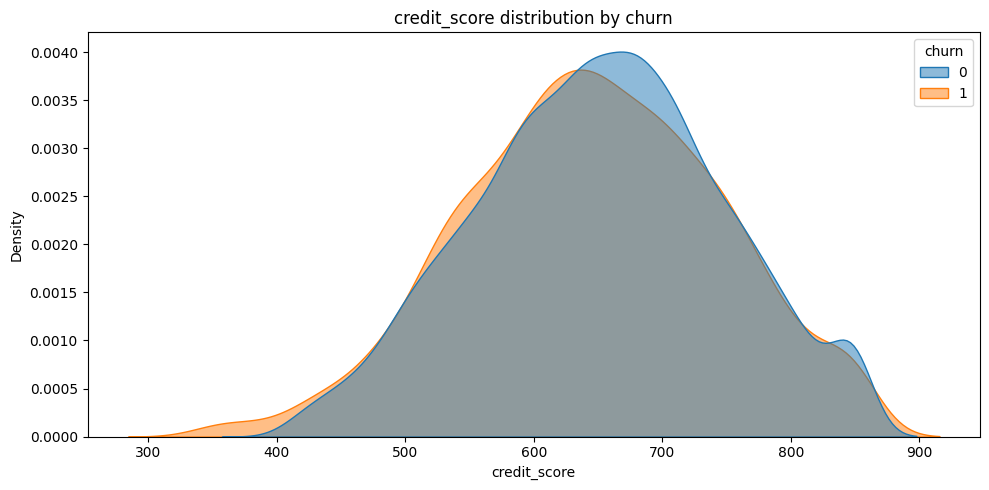

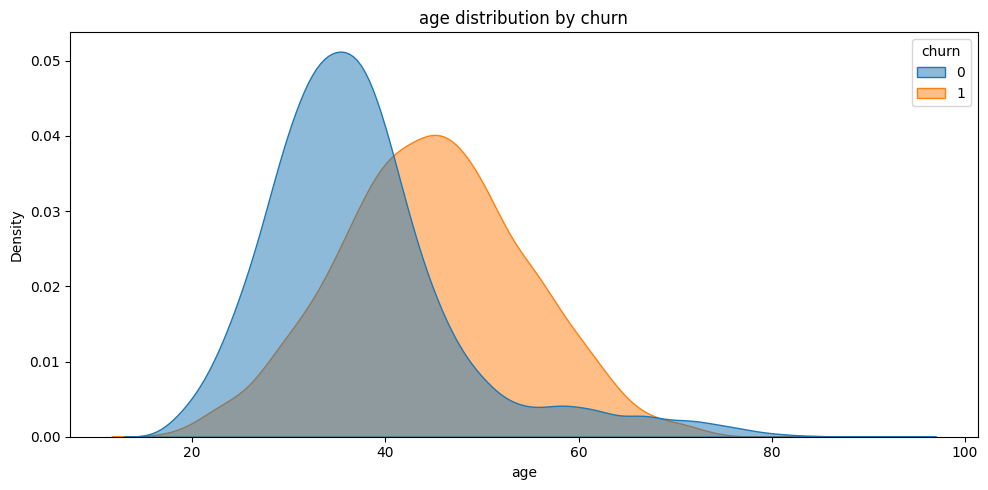

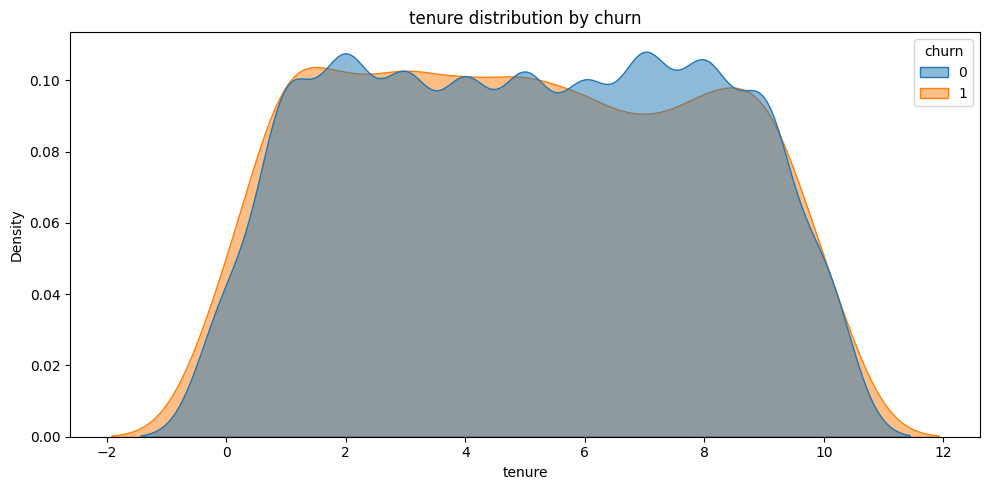

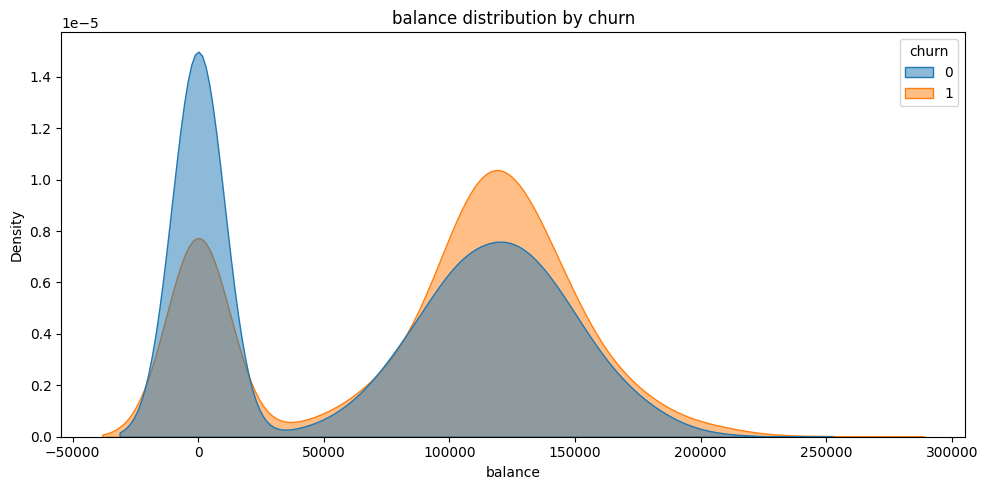

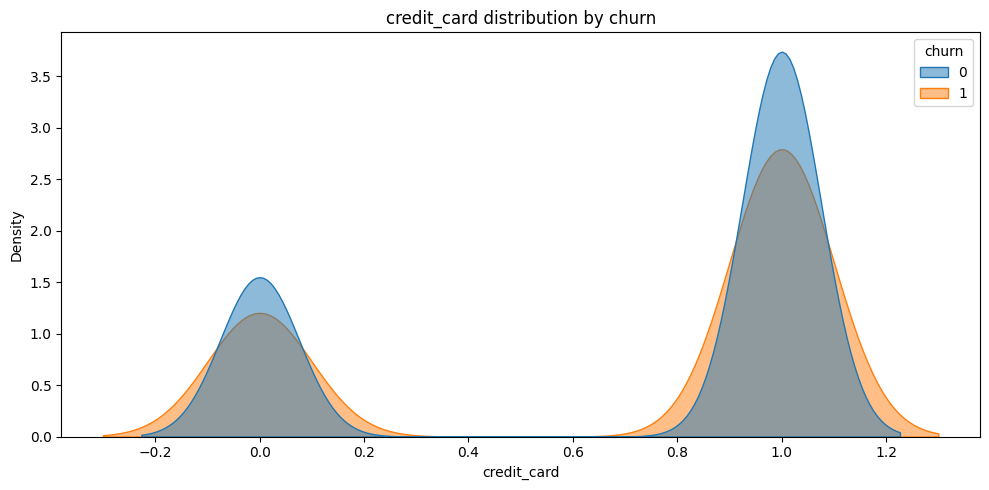

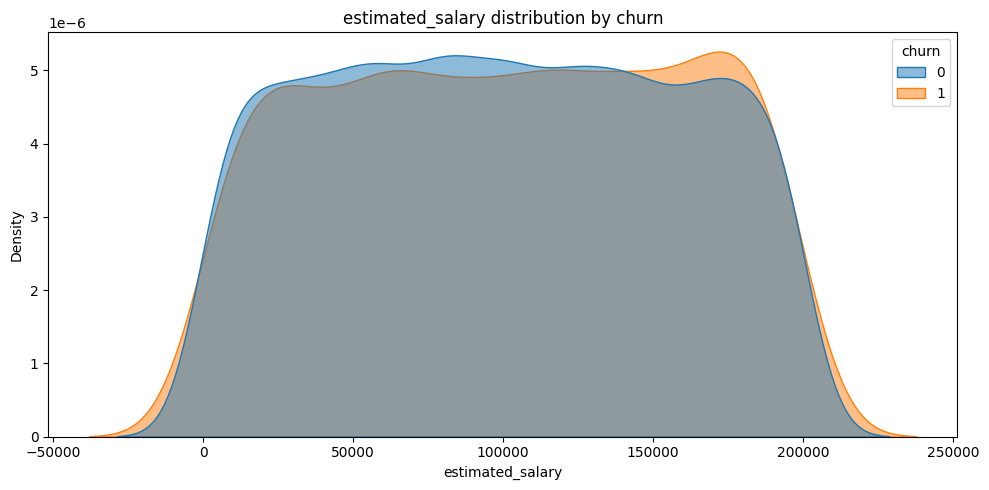

In [21]:
col_name = ['credit_score','age','tenure','balance','credit_card','estimated_salary',]
for i in col_name:
    plt.figure(figsize = (10,5))
    sns.kdeplot(data=df, x=i, hue='churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{i} distribution by churn')
    plt.tight_layout()
    plt.show()


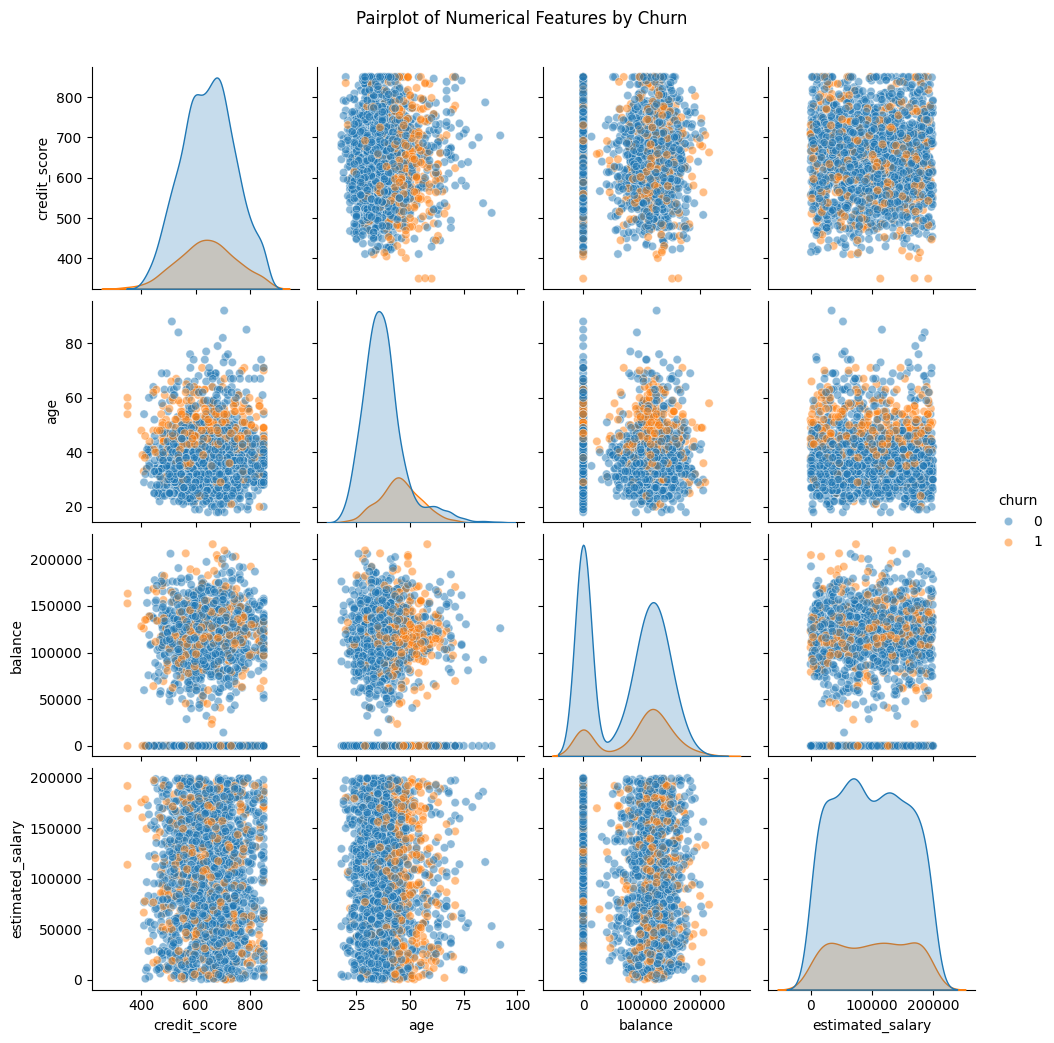

In [24]:
sns.pairplot(df.sample(frac=0.2, random_state=42), vars=['credit_score','age','balance','estimated_salary'], diag_kind='kde', hue='churn',plot_kws = {'alpha':0.5})
plt.suptitle('Pairplot of Numerical Features by Churn', y=1.04)
plt.show()

C:\Users\Vikas Prajapati\AppData\Local\Temp\ipykernel_22384\2920101335.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn', y='age', palette='Set2')


<Figure size 1200x600 with 0 Axes>

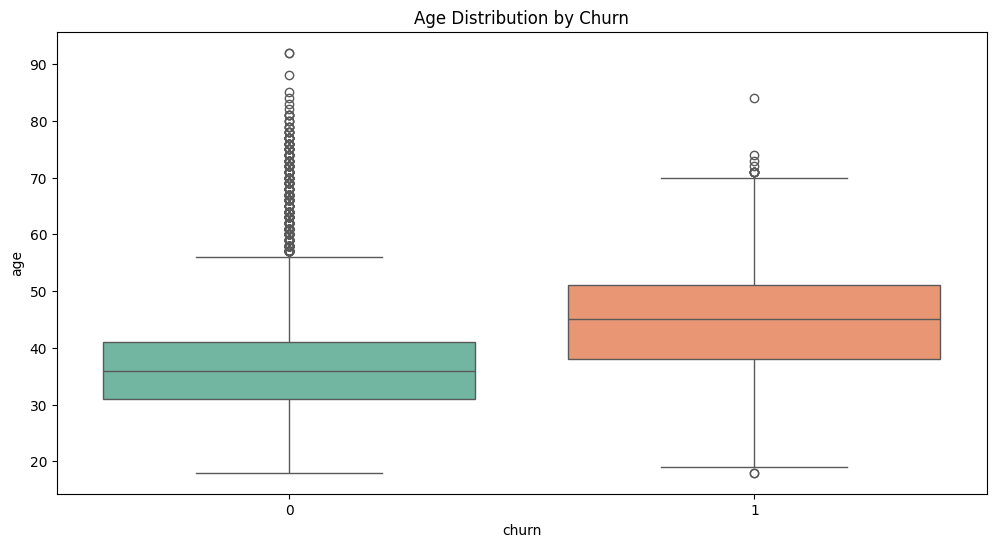

In [30]:
plt.figure(figsize=(12,6))
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='churn', y='age', palette='Set2')
plt.title('Age Distribution by Churn')
plt.show()


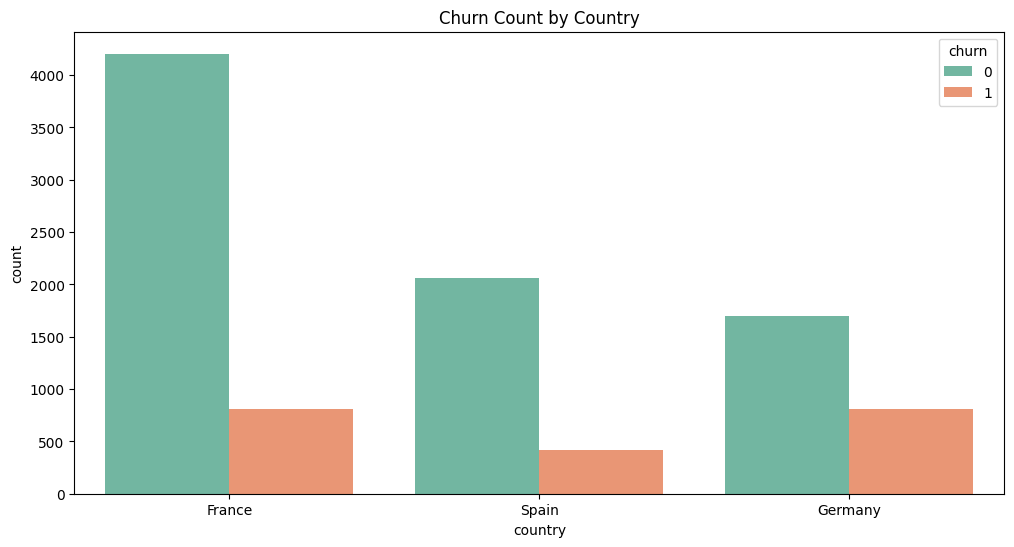

In [32]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='country', hue='churn', palette='Set2')
plt.title('Churn Count by Country')   
plt.show() 

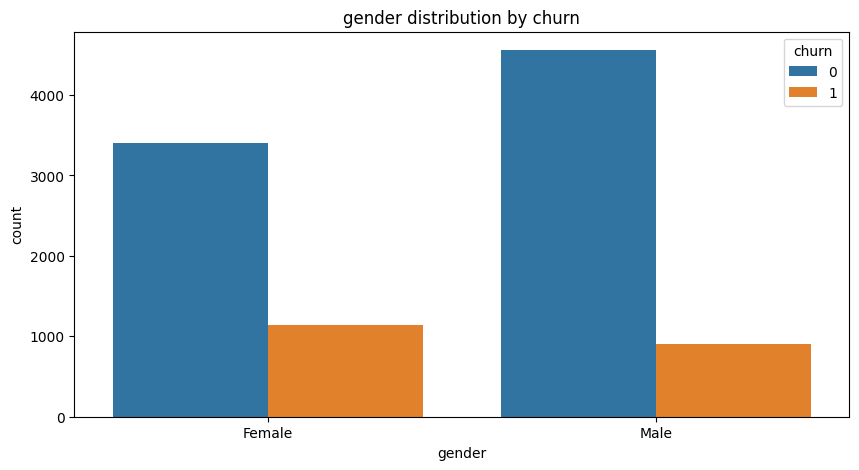

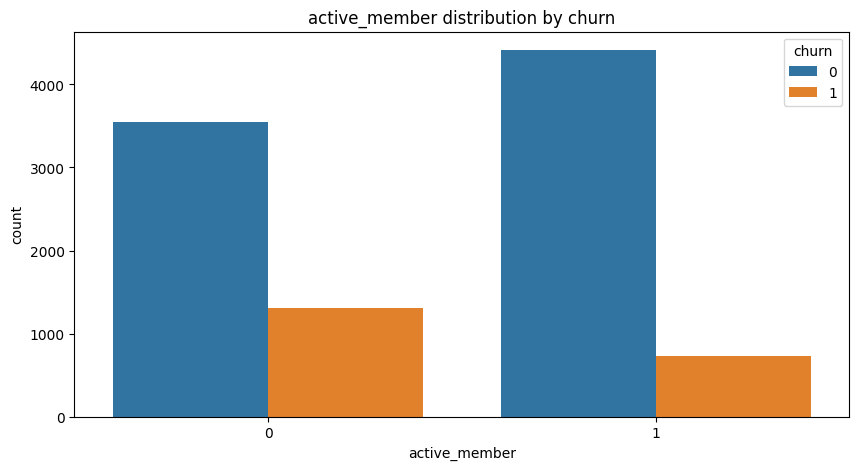

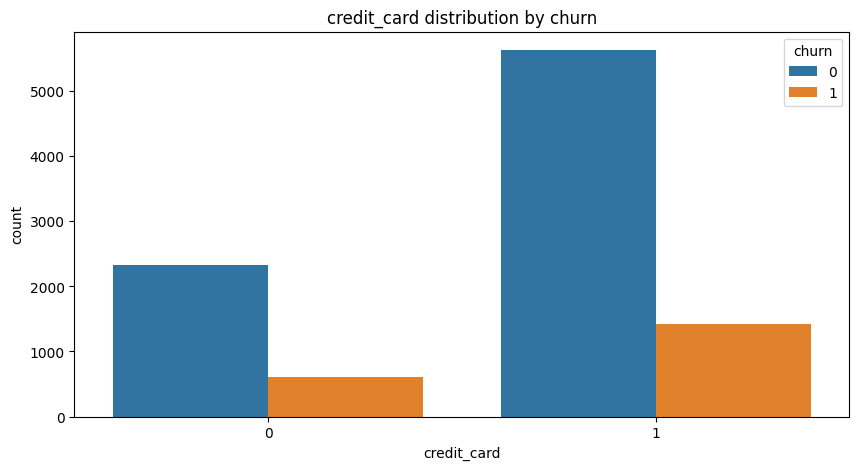

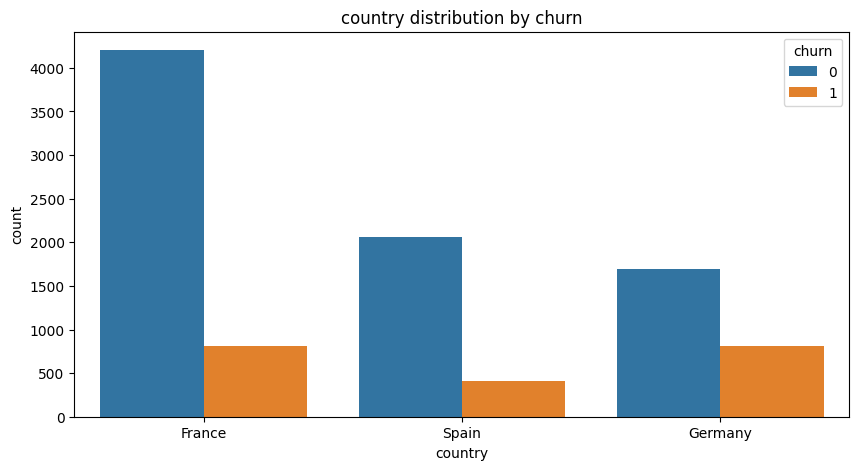

In [34]:
clou_name = ['gender','active_member','credit_card','country']
for c in clou_name:
    plt.figure(figsize=(10,5))
    sns.countplot(data= df, x= c, hue='churn')
    plt.title(f'{c} distribution by churn') 
    plt.show()  

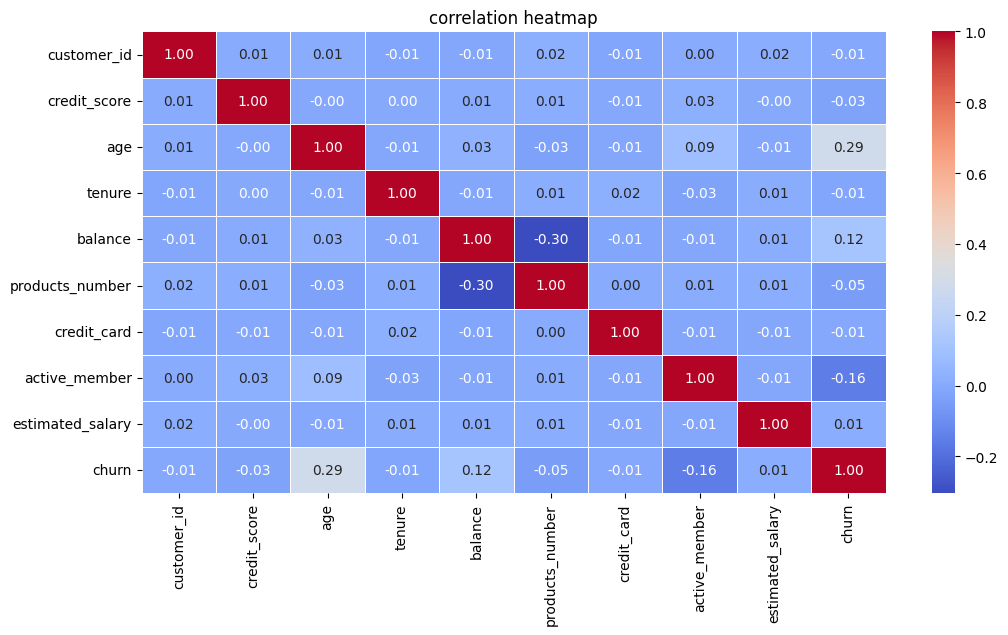

In [40]:
plt.figure(figsize=(12,6))
sns.heatmap(data=df.corr(numeric_only=True), fmt='.2f', annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('correlation heatmap')
plt.show()

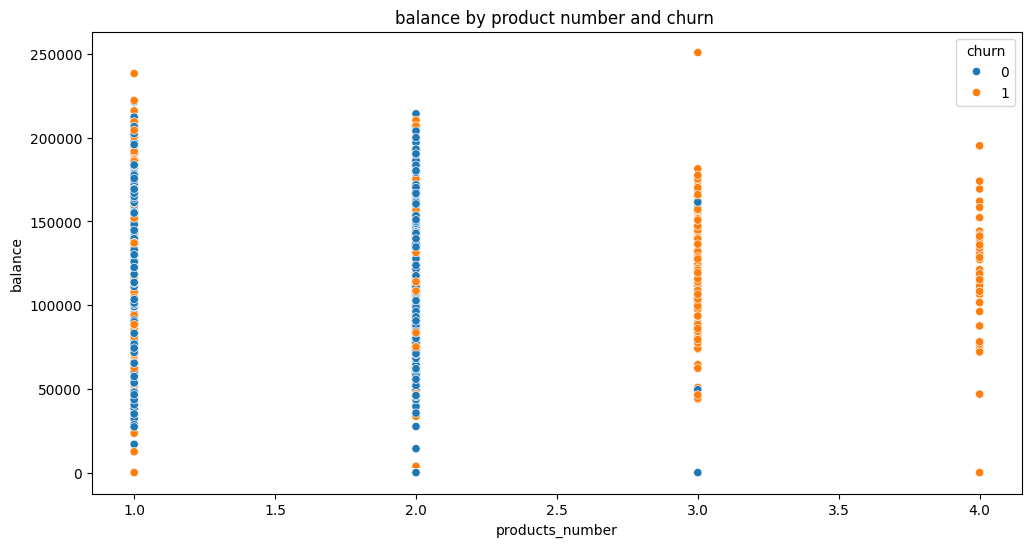

In [43]:
plt.figure(figsize=(12,6))  
sns.scatterplot(data=df,x='products_number', y='balance' ,hue='churn')
plt.title('balance by product number and churn ')
plt.show()

C:\Users\Vikas Prajapati\AppData\Local\Temp\ipykernel_22384\10154451.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= churn_rate, x='products_number',y='churn',palette='viridis')


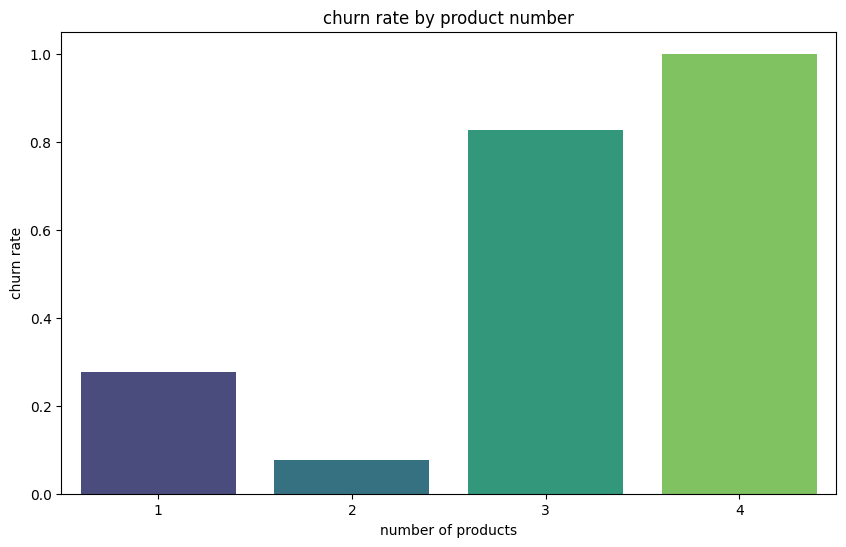

In [45]:
churn_rate=df.groupby('products_number')['churn'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data= churn_rate, x='products_number',y='churn',palette='viridis')
plt.xlabel('number of products')

plt.ylabel('churn rate')
plt.title('churn rate by product number')
plt.show()